In [1]:
import requests
import json

cities = {
    "Delhi": (28.61, 77.20),
    "Dhaka": (23.81, 90.41),
    "Manila": (14.60, 120.98)
}

data = []

for city, (lat, lon) in cities.items():

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum&timezone=auto"

    response = requests.get(url)
    weather = response.json()

    rainfall = weather["daily"]["precipitation_sum"][0]

    data.append({
        "city": city,
        "rainfall": rainfall
    })

with open("weather_data.json", "w") as f:
    json.dump(data, f, indent=4)

print("Weather data collected successfully!")

Weather data collected successfully!


In [2]:
for city in data:

    rainfall = city["rainfall"]

    if rainfall > 120:
        city["risk"] = "EXTREME"

    elif rainfall > 80:
        city["risk"] = "HIGH"

    elif rainfall > 40:
        city["risk"] = "MEDIUM"

    else:
        city["risk"] = "LOW"

data

[{'city': 'Delhi', 'rainfall': 0.0, 'risk': 'LOW'},
 {'city': 'Dhaka', 'rainfall': 14.6, 'risk': 'LOW'},
 {'city': 'Manila', 'rainfall': 0.0, 'risk': 'LOW'}]

In [3]:
import matplotlib.pyplot as plt

cities = [city["city"] for city in data]
rainfall = [city["rainfall"] for city in data]

plt.figure()

plt.bar(cities, rainfall)

plt.title("Rainfall Monitoring - Asia Cities")

plt.xlabel("City")

plt.ylabel("Rainfall (mm)")

plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [4]:
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


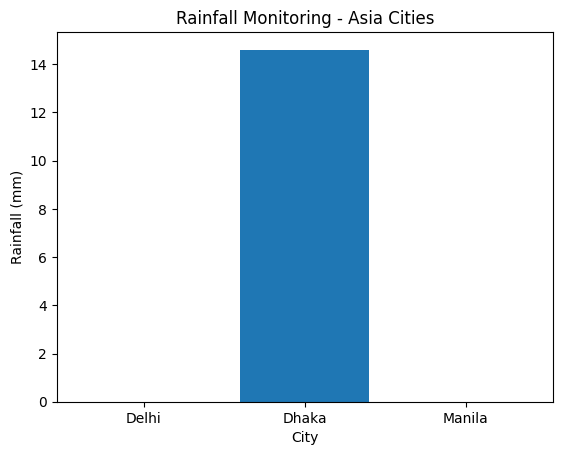

In [5]:
import matplotlib.pyplot as plt

cities = [city["city"] for city in data]
rainfall = [city["rainfall"] for city in data]

plt.figure()

plt.bar(cities, rainfall)

plt.title("Rainfall Monitoring - Asia Cities")

plt.xlabel("City")

plt.ylabel("Rainfall (mm)")

plt.show()

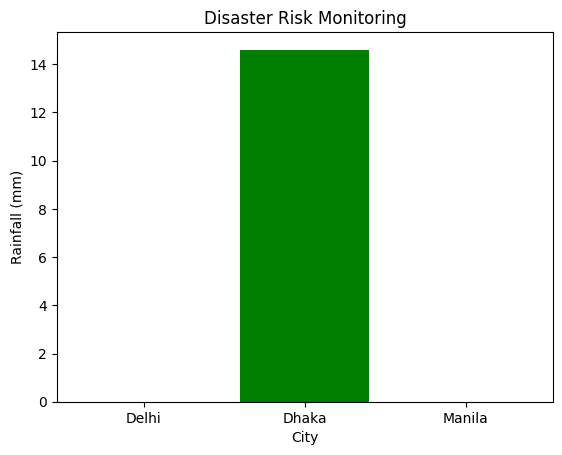

In [6]:
import matplotlib.pyplot as plt

cities = [city["city"] for city in data]
rainfall = [city["rainfall"] for city in data]

colors = []

for city in data:

    if city["risk"] == "LOW":
        colors.append("green")

    elif city["risk"] == "MEDIUM":
        colors.append("orange")

    elif city["risk"] == "HIGH":
        colors.append("red")

    else:
        colors.append("darkred")

plt.figure()

plt.bar(cities, rainfall, color=colors)

plt.title("Disaster Risk Monitoring")

plt.xlabel("City")
plt.ylabel("Rainfall (mm)")

plt.show()

In [7]:
import json

with open("weather_data.json", "w") as f:
    json.dump(data, f, indent=4)

print("Risk data saved successfully!")

Risk data saved successfully!


In [8]:
!pip install folium


   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import folium

# create map centered in Asia
m = folium.Map(location=[20, 90], zoom_start=4)

# city coordinates
coords = {
    "Delhi": [28.61, 77.20],
    "Dhaka": [23.81, 90.41],
    "Manila": [14.60, 120.98]
}

# add markers
for city in data:

    city_name = city["city"]
    rainfall = city["rainfall"]
    risk = city["risk"]

    folium.Marker(
        location=coords[city_name],
        popup=f"{city_name} | Rainfall: {rainfall} mm | Risk: {risk}"
    ).add_to(m)

m

In [10]:
m.save("disaster_dashboard.html")

print("Dashboard exported!")

Dashboard exported!


In [11]:
import folium

m = folium.Map(location=[20, 90], zoom_start=4)

coords = {
    "Delhi": [28.61, 77.20],
    "Dhaka": [23.81, 90.41],
    "Manila": [14.60, 120.98]
}

for city in data:

    city_name = city["city"]
    rainfall = city["rainfall"]
    risk = city["risk"]

    if risk == "LOW":
        color = "green"
    elif risk == "MEDIUM":
        color = "orange"
    elif risk == "HIGH":
        color = "red"
    else:
        color = "darkred"

    folium.Marker(
        location=coords[city_name],
        popup=f"{city_name} | Rainfall: {rainfall} mm | Risk: {risk}",
        icon=folium.Icon(color=color)
    ).add_to(m)

m

In [12]:
m.save("disaster_dashboard.html")

In [1]:
cities = {
    "Delhi": (28.61, 77.20),
    "Dhaka": (23.81, 90.41),
    "Manila": (14.60, 120.98),
    "Bangkok": (13.75, 100.50),
    "Jakarta": (-6.20, 106.85),
    "Karachi": (24.86, 67.01),
    "Tokyo": (35.68, 139.69),
    "Seoul": (37.56, 126.97)
}

In [2]:
import requests

data = []

for city, (lat, lon) in cities.items():

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum&timezone=auto"

    response = requests.get(url)
    weather = response.json()

    rainfall = weather["daily"]["precipitation_sum"][0]

    data.append({
        "city": city,
        "rainfall": rainfall
    })

data

[{'city': 'Delhi', 'rainfall': 0.0},
 {'city': 'Dhaka', 'rainfall': 14.6},
 {'city': 'Manila', 'rainfall': 0.0},
 {'city': 'Bangkok', 'rainfall': 0.2},
 {'city': 'Jakarta', 'rainfall': 0.0},
 {'city': 'Karachi', 'rainfall': 0.0},
 {'city': 'Tokyo', 'rainfall': 0.0},
 {'city': 'Seoul', 'rainfall': 0.0}]

In [3]:
for city in data:

    rainfall = city["rainfall"]

    if rainfall > 120:
        city["risk"] = "EXTREME"
    elif rainfall > 80:
        city["risk"] = "HIGH"
    elif rainfall > 40:
        city["risk"] = "MEDIUM"
    else:
        city["risk"] = "LOW"

data

[{'city': 'Delhi', 'rainfall': 0.0, 'risk': 'LOW'},
 {'city': 'Dhaka', 'rainfall': 14.6, 'risk': 'LOW'},
 {'city': 'Manila', 'rainfall': 0.0, 'risk': 'LOW'},
 {'city': 'Bangkok', 'rainfall': 0.2, 'risk': 'LOW'},
 {'city': 'Jakarta', 'rainfall': 0.0, 'risk': 'LOW'},
 {'city': 'Karachi', 'rainfall': 0.0, 'risk': 'LOW'},
 {'city': 'Tokyo', 'rainfall': 0.0, 'risk': 'LOW'},
 {'city': 'Seoul', 'rainfall': 0.0, 'risk': 'LOW'}]

In [6]:
import requests
import folium

# Cities and coordinates
cities = {
    "Delhi": (28.61, 77.20),
    "Dhaka": (23.81, 90.41),
    "Manila": (14.60, 120.98),
    "Bangkok": (13.75, 100.50),
    "Jakarta": (-6.20, 106.85),
    "Karachi": (24.86, 67.01),
    "Tokyo": (35.68, 139.69),
    "Seoul": (37.56, 126.97)
}

data = []

# Collect weather data
for city, (lat, lon) in cities.items():

    url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&daily=precipitation_sum&timezone=auto"

    response = requests.get(url)
    weather = response.json()

    rainfall = weather["daily"]["precipitation_sum"][0]

    # Risk classification
    if rainfall > 120:
        risk = "EXTREME"
        color = "darkred"
    elif rainfall > 80:
        risk = "HIGH"
        color = "red"
    elif rainfall > 40:
        risk = "MEDIUM"
        color = "orange"
    else:
        risk = "LOW"
        color = "green"

    data.append({
        "city": city,
        "rainfall": rainfall,
        "risk": risk
    })

# Create map
m = folium.Map(location=[20, 100], zoom_start=4)

for city in data:

    name = city["city"]
    rainfall = city["rainfall"]
    risk = city["risk"]

    folium.Marker(
        location=cities[name],
        popup=f"{name} | Rainfall: {rainfall} mm | Risk: {risk}",
        icon=folium.Icon(color=color)
    ).add_to(m)

# Save dashboard
m.save("disaster_dashboard.html")

print("Dashboard created successfully!")

m

Dashboard created successfully!


In [7]:
import requests

url = "https://api.open-meteo.com/v1/forecast?latitude=28.61&longitude=77.20&daily=precipitation_sum&timezone=auto"
response = requests.get(url)

print(response.json())

{'latitude': 28.625, 'longitude': 77.25, 'generationtime_ms': 0.02562999725341797, 'utc_offset_seconds': 19800, 'timezone': 'Asia/Kolkata', 'timezone_abbreviation': 'GMT+5:30', 'elevation': 221.0, 'daily_units': {'time': 'iso8601', 'precipitation_sum': 'mm'}, 'daily': {'time': ['2026-03-13', '2026-03-14', '2026-03-15', '2026-03-16', '2026-03-17', '2026-03-18', '2026-03-19'], 'precipitation_sum': [0.0, 0.5, 0.1, 0.0, 0.0, 0.0, 1.2]}}


In [9]:
import os

os.listdir()

['.idea',
 '.ipynb_checkpoints',
 '.venv',
 'data',
 'disaster_dashboard.html',
 'models',
 'README.md',
 'requirements.txt',
 'sample.ipynb',
 'weather_data.json',
 'weather_fetcher.ipynb']